In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Neurolib imports
from neurolib.models.hopf import HopfModel
from neurolib.utils.loadData import Dataset
from neurolib.optimize.evolution import Evolution
from neurolib.utils.functions import matrix_correlation

MainProcess root INFO     Loading dataset hcp from /home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/neurolib/utils/../data/datasets/hcp.
MainProcess root INFO     Dataset hcp loaded.
MainProcess root INFO     hopf: Model initialized.
MainProcess root INFO     Assuming parameter kind "bound"
MainProcess root INFO     Trajectory Name: results-2026-01-13-17H-08M-23S
MainProcess root INFO     Storing data to: ./data/hdf/hopf_fit.hdf
MainProcess root INFO     Trajectory Name: results-2026-01-13-17H-08M-23S
MainProcess root INFO     Number of cores: 14
MainProcess pypet.storageservice.HDF5StorageService INFO     I will use the hdf5 file `./data/hdf/hopf_fit.hdf`.
MainProcess pypet.environment.Environment INFO     Environment initialized.
MainProcess root INFO     Evolution: Using algorithm: nsga2
MainProcess root INFO     Evolution: Individual generation: <function randomParameters at 0x7183d398ec00>
MainProcess root INFO     Evolution: Mating operator: <function cxSim

> Simulation parameters
HDF file storage: ./data/hdf/hopf_fit.hdf
Trajectory Name: results-2026-01-13-17H-08M-23S
Duration of evaluating initial population 0:01:42.110780
Duration of evolution 0:14:29.797617
Model: <class 'neurolib.models.hopf.model.HopfModel'>
Model name: hopf
Eval function: <function evaluate_simulation at 0x7183d1293740>
Parameter space: {'a': [-2.0, 2.0], 'K_gl': [0.0, 2.0], 'sigma_ou': [0.0, 0.3]}
> Evolution parameters
Number of generations: 10
Initial population size: 16
Population size: 16
> Evolutionary operators
Mating operator: <function cxSimulatedBinaryBounded at 0x7183d3a1a8e0>
Mating paramter: {'low': [-2.0, 0.0, 0.0], 'up': [2.0, 2.0, 0.3], 'eta': 20.0}
Selection operator: <function selNSGA2 at 0x7183d3a1ae80>
Selection paramter: {}
Parent selection operator: <function selTournamentDCD at 0x7183d3a1b060>
Comments: no comments
--- Info summary ---
Valid: 16
Mean score (weighted fitness): 0.32
Parameter distribution (Generation 9):
a: 	 mean: 1.5610,	 std

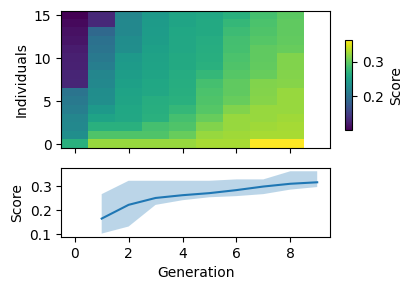

MainProcess root INFO     Saving plot to ./data/figures/results-2026-01-13-17H-08M-23S_hist_9.png


There are 16 valid individuals
Mean score across population: 0.32


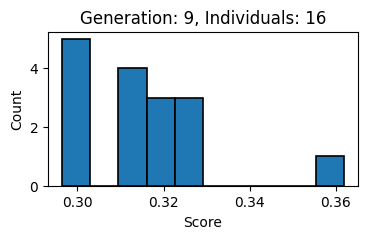

<Figure size 640x480 with 0 Axes>

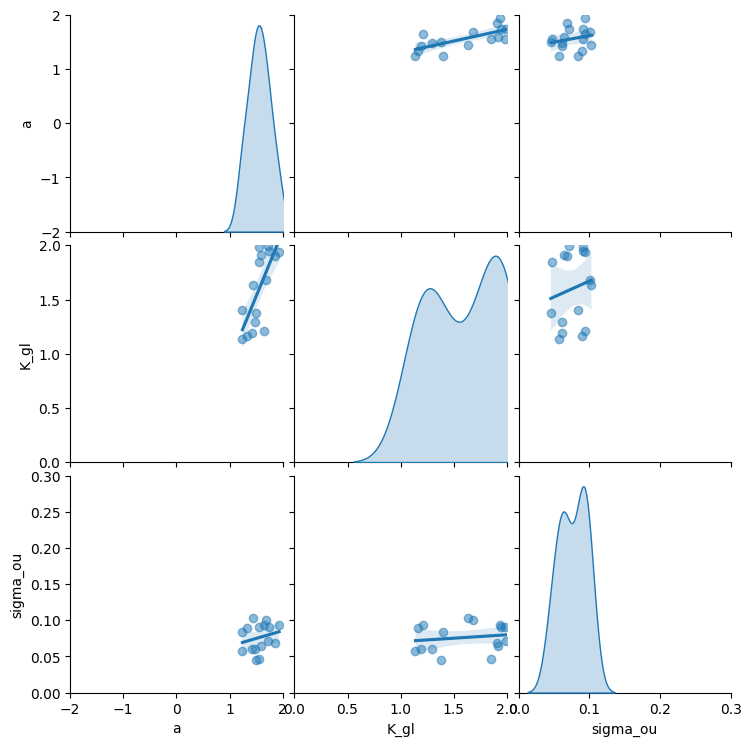

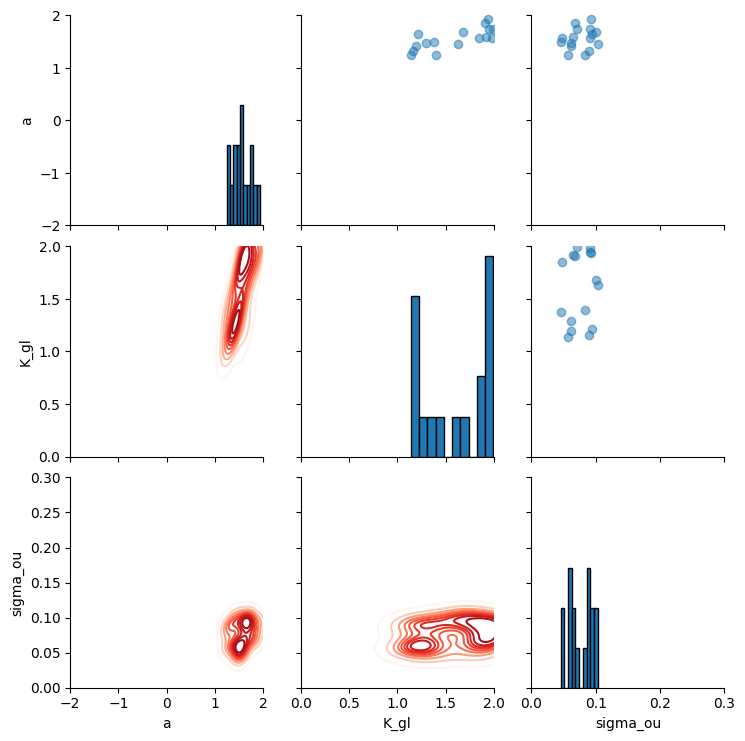

In [6]:
import numpy as np

from neurolib.models.hopf import HopfModel
from neurolib.utils.loadData import Dataset
import neurolib.utils.functions as func

from neurolib.utils.parameterSpace import ParameterSpace
from neurolib.optimize.evolution import Evolution

# -----------------------
# Load demo empirical data
# -----------------------
ds = Dataset("hcp")  # provides ds.Cmat, ds.Dmat, ds.BOLDs, ds.FCs, ...
# Dataset format: structural matrices are NxN and fMRI timeseries are NxT.  :contentReference[oaicite:8]{index=8}

# -----------------------
# Build Hopf whole-brain model
# -----------------------
model = HopfModel(Cmat=ds.Cmat, Dmat=ds.Dmat)
model.params["signalV"] = 0          # which state couples (as in Hopf example)
model.params["dt"] = 0.1             # ms (keep small enough for stability)
model.params["duration"] = 60_000.0  # ms (60s) - raise for real fitting
model.params["bold"] = True          # not always needed as a param, but we will run with bold=True

# Fix any parameters you do NOT want to fit:
model.params["w"] = 1.0              # you can also fit it
# model.params["a"] = 0.0            # you can also fit it

# -----------------------
# Fitness: FC correlation (optionally add FCD etc.)
# -----------------------
def evaluate_simulation(traj):
    m = evolution.getModelFromTraj(traj)   # inject candidate parameters
    default_duration = m.params["duration"]

    # --- quick reject stage (saves time) ---
    m.params["duration"] = 5_000.0
    m.run()
    if np.any(~np.isfinite(m.x)) or np.max(np.abs(m.x)) > 1e3:
        return (np.nan,), {}

    # --- full run with BOLD ---
    m.params["duration"] = default_duration
    m.run(chunkwise=True, bold=True)

    # Discard BOLD transient
    transient_ms = 10_000.0
    bold = m.BOLD.BOLD[:, m.BOLD.t_BOLD > transient_ms]  # NxT_BOLD

    fc_sim = func.fc(bold)

    # Compare to empirical FCs (mean across subjects)
    score = float(np.mean([func.matrix_correlation(fc_sim, fc_emp) for fc_emp in ds.FCs]))
    return (score,), {}

# -----------------------
# Define search space
# -----------------------
# Typical Hopf fit parameters in neurolib examples: a, K_gl, sigma_ou (and sometimes w).
pars = ParameterSpace(
    ["a", "K_gl", "sigma_ou"],
    [[-2.0, 2.0], [0.0, 2.0], [0.0, 0.3]]
)

# -----------------------
# Run evolutionary optimization
# -----------------------
evolution = Evolution(
    evaluate_simulation,
    pars,
    algorithm="nsga2",
    weightList=[1.0],         # maximize the single returned fitness value
    model=model,
    POP_INIT_SIZE=16,
    POP_SIZE=16,
    NGEN=10,
    filename="hopf_fit.hdf",
)

evolution.run(verbose=False)

# Inspect best individuals / summary
evolution.info()
